In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

df = pd.read_csv("data/combined_data.csv")
df.head()

,id,price,property_type,accommodates,bathrooms,bedrooms,beds,neighbourhood_cleansed,latitude,longitude,...,booked_spring,booked_summer,booked_fall,booked_range,num_reviews_sampled,avg_sentiment_score,num_reviews_total,sentiment_label,district_group,district
0,49287,93.0,11,3,1.0,1.0,1.0,78,37.398980,-5.995330,...,5,0,55,0.330097,30.0,0.8067,40.0,Positiv,Casco Antiguo,San Lorenzo
1,108236,120.0,11,5,1.0,2.0,3.0,83,37.396858,-5.999127,...,0,0,5,0.063291,30.0,0.7995,222.0,Positiv,Casco Antiguo,San Vicente
2,111140,89.0,4,4,1.0,1.0,2.0,83,37.395924,-5.999317,...,21,0,54,1.000000,30.0,0.5476,63.0,Positiv,Casco Antiguo,San Vicente
3,179629,146.0,11,5,1.0,3.0,4.0,87,37.387310,-5.990950,...,42,0,58,0.551020,30.0,0.7798,205.0,Positiv,Casco Antiguo,Santa Cruz
4,207702,85.0,11,2,1.0,1.0,1.0,57,37.389450,-5.998890,...,0,0,38,0.540541,30.0,0.7747,508.0,Positiv,Casco Antiguo,Museo


In [2]:
df = df.drop(["id", "name", "description", "amenities"], axis=1)

categorical_cols = ["sentiment_label", "district_group", "district"]
for col in categorical_cols:
    df[col] = df[col].fillna("unknown").astype("category")

X = df.drop("price", axis=1)
y = df["price"]

print(X.shape)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Training: {X_train.shape}   Test: {X_test.shape}")

(7426, 39)
Training: (5940, 39)   Test: (1486, 39)


In [3]:
model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method="hist",
    enable_categorical=True,
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=50,
    eval_metric="mae",
)
model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False,
)
print(f"Beste Iteration: {model.best_iteration}")

Beste Iteration: 323


In [4]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE:  {mae:.2f}\u20ac")
print(f"RMSE: {rmse:.2f}\u20ac")
print(f"R2:   {r2:.3f}")

MAE:  40.29€
RMSE: 73.68€
R2:   0.521


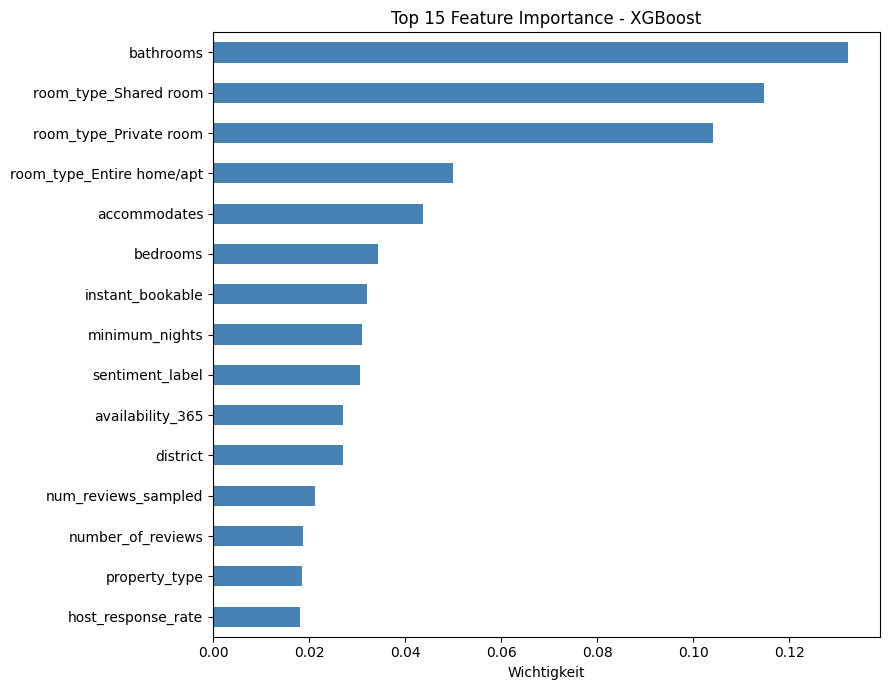

In [5]:
feature_importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(9, 7))
feature_importance.head(15).sort_values().plot(kind="barh", color="steelblue")
plt.title("Top 15 Feature Importance - XGBoost")
plt.xlabel("Wichtigkeit")
plt.tight_layout()
plt.savefig("feature_importance_xgboost.png")
plt.show()

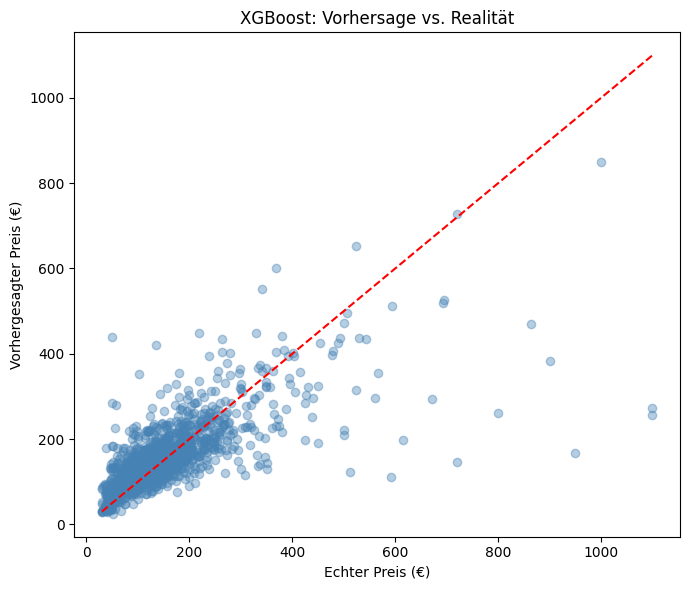

In [6]:
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred, alpha=0.4, color="steelblue")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
plt.xlabel("Echter Preis (\u20ac)")
plt.ylabel("Vorhergesagter Preis (\u20ac)")
plt.title("XGBoost: Vorhersage vs. Realität")
plt.tight_layout()
plt.show()

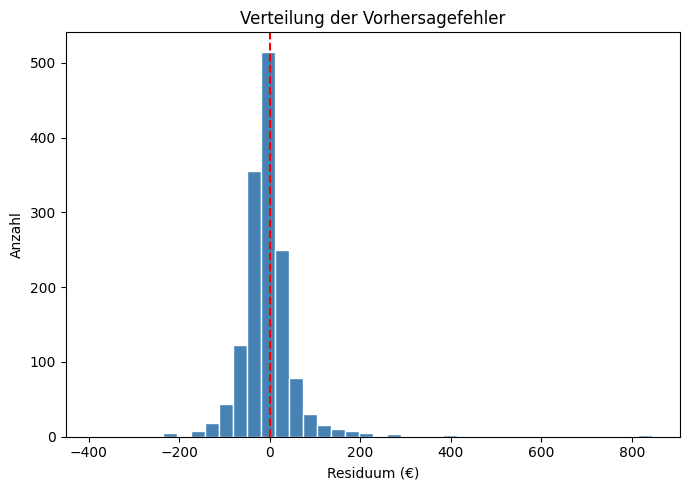

In [7]:
residuals = y_test - y_pred

plt.figure(figsize=(7, 5))
plt.hist(residuals, bins=40, color="steelblue", edgecolor="white")
plt.axvline(0, color="red", linestyle="--")
plt.xlabel("Residuum (\u20ac)")
plt.ylabel("Anzahl")
plt.title("Verteilung der Vorhersagefehler")
plt.tight_layout()
plt.show()